# Lab 1: Statistics

In [73]:
#importing packages
import scipy as sp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import scipy.integrate as integrate
import math

plt.rcParams["figure.figsize"] = (15,10)

## Continous Distributions

1. probability and sigma investigated with distribution functions

### 1.B

In [74]:
#results for 1.B

# creating dictionary with z-table values
z_value_dict = {"-.1": 0.46017, "-.5":0.30854, "-1.0":0.15866}

# calculating sigma from cdf
sigma_1 = stats.norm.cdf(-.1,0,1)
sigma_2 = stats.norm.cdf(-.5,0,1)
sigma_3 = stats.norm.cdf(-1.0,0,1)

result_list = [sigma_1, sigma_2, sigma_3]

print("comparison of z table values and usage of cumulative distribution function for normal distribution:")
print("z = -.1")
print("- cumulative distribution function for x = -.1: {}".format(result_list[0]))
print("- actual z table value for z = -.1: {}".format(z_value_dict["-.1"]))

print("z = -.5")
print("- cumulative distribution function for x = -.5: {}".format(result_list[1]))
print("- actual z table value for z = -.5: {}".format(z_value_dict["-.5"]))

print("z = -1.0")
print("- cumulative distribution function for x = -.5: {}".format(result_list[2]))
print("- actual z table value for z = -.5: {}".format(z_value_dict["-1.0"]))


comparison of z table values and usage of cumulative distribution function for normal distribution:
z = -.1
- cumulative distribution function for x = -.1: 0.460172162722971
- actual z table value for z = -.1: 0.46017
z = -.5
- cumulative distribution function for x = -.5: 0.3085375387259869
- actual z table value for z = -.5: 0.30854
z = -1.0
- cumulative distribution function for x = -.5: 0.15865525393145707
- actual z table value for z = -.5: 0.15866


### 1.C

In [75]:
# showing given percentiles can be transformed to related sigma of normal distribution

sigma_1 = stats.norm.ppf(.46, loc=0, scale=1) # probability is associated with .1 sigma
sigma_2 = stats.norm.ppf(.02275, loc=0, scale=1) # probability is associated with 2 sigma
sigma_3 = stats.norm.ppf(.00135, loc=0, scale=1) # probability is associated with 3 sigma

sigmas = [sigma_1, sigma_2, sigma_3]

print(sigmas)


[np.float64(-0.10043372051146975), np.float64(-2.0000024438996036), np.float64(-2.9999769927033935)]


### 1.D
A negative value appears because the z value in the z table table would be negative. in other words, one would need to integrate the normal function from the left from infinity to -.1 sigma to get 46% of the area of the distribution. 

### 2.B

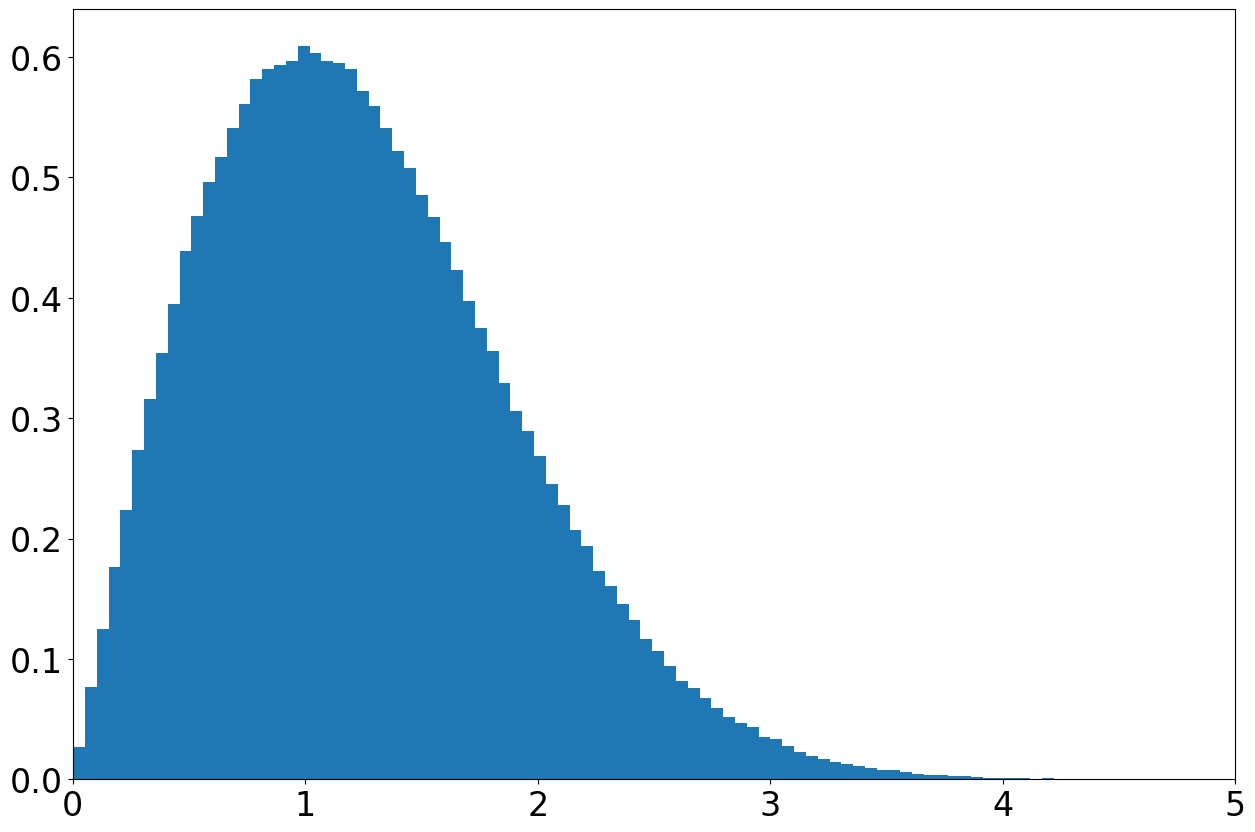

In [76]:

#creating array with points picked from rayleigh distribution starting from 0 with a scale of 1
d = stats.rayleigh.rvs(loc = 0, scale = 1, size = 1000000)

#the points in d are plotted using a histogram
ax = plt.hist(d,100, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([0,5])
plt.show()



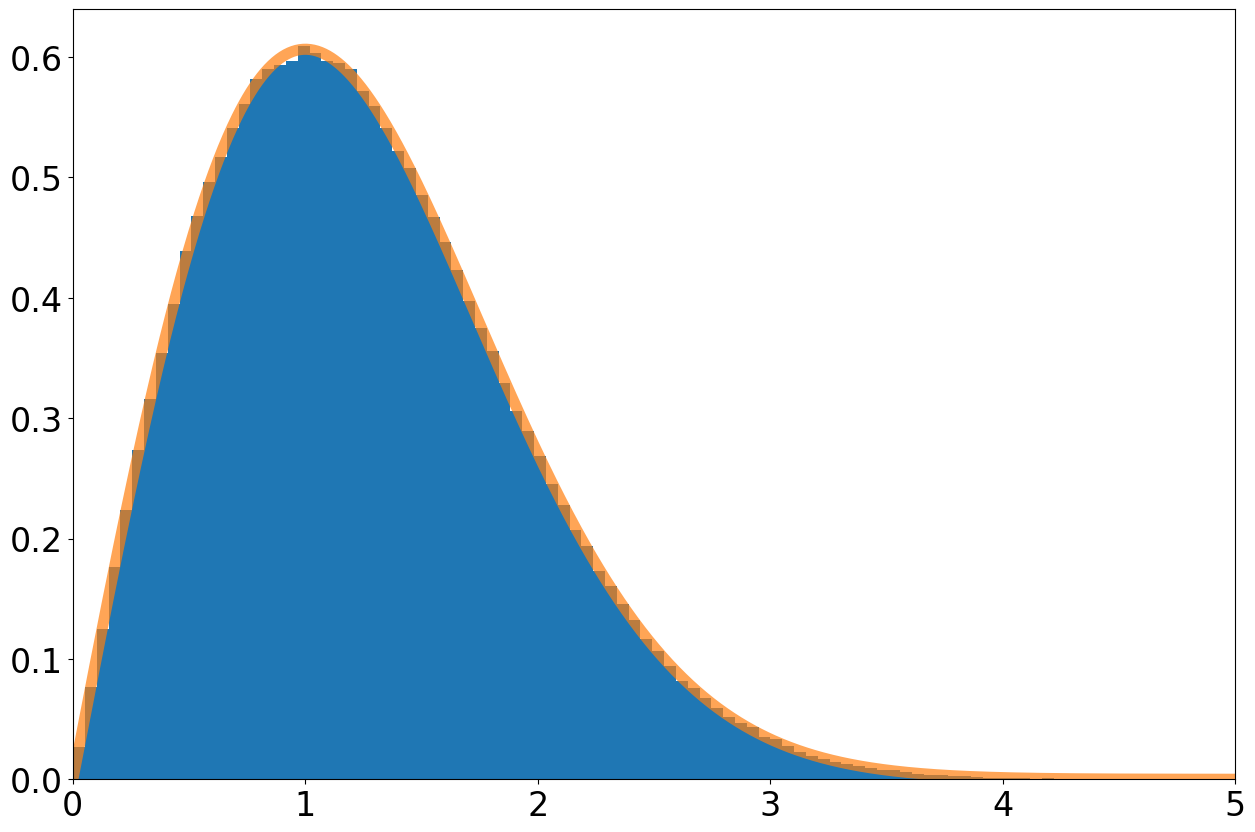

In [77]:
# making the same plot as above but with the probability distribution itself plotted with the histogram

fig, ax = plt.subplots(1, 1)
ax.hist(d,100, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([0,5])

x = np.linspace(0,5,1000)
# this is the probability density function
ax.plot(x,stats.rayleigh.pdf(x,loc = 0.0, scale = 1),linewidth = 8,alpha = 0.7)

plt.show()

## 3. Determining the 'sigma'
Consider we measure a result of 4 and we have a signal-less distribution that takes the form of a Rayleigh distribution. We then want to know what probability such a measurement of equal or greater magnitude can occur and then convert such a percentage value to a value of sigma defined as the sigma of a normal distribution that would be reached if we integrated the same percentage area of the probability distribution function from the right.

In [78]:
# calculating the probability that a value equal to or less than the value of 4 is measured
prob_measure_less = stats.rayleigh.cdf(4,0,1)

# This next step gives the probability that we could measure a value greater than 4 if measuring from signal-less 
# Rayleigh distribution:
prob_measure_more = 1 - prob_measure_less
prob_measure = prob_measure_more * 100.0 # to get in percentile

# To get the sigma we want, we can take our initial probability of measuring less than 4 and plug it into the
# normal distribution ppf function
sigma_measure_4 = stats.norm.ppf(prob_measure_less, loc=0, scale=1)

print("percentage of signal-less measurements that could have produced a value of 4: {}%".format(prob_measure))
print("sigma value of: {}".format(sigma_measure_4))


percentage of signal-less measurements that could have produced a value of 4: 0.033546262790251635%
sigma value of: 3.4011926561446617


## 4. Determining the 'sigma' with other measurement values

In [79]:
# calculating the probability that a value equal to or less than the value of 5 is measured
prob_measure_less = stats.rayleigh.cdf(5,0,1)

# This next step gives the probability that we could measure a value greater than 4 if measuring from signal-less 
# Rayleigh distribution:
prob_measure_more = 1 - prob_measure_less
prob_measure = prob_measure_more * 100.0 # to get in percentile

# To get the sigma we want, we can take our initial probability of measuring less than 4 and plug it into the
# normal distribution ppf function
sigma_measure_4 = stats.norm.ppf(prob_measure_less, loc=0, scale=1)

print("percentage of signal-less measurements that could have produced a value of 4: {}%".format(prob_measure))
print("sigma value of: {}".format(sigma_measure_4))

percentage of signal-less measurements that could have produced a value of 4: 0.00037266531720536733%
sigma value of: 4.4803146987717914


In [80]:
# calculating the probability that a value equal to or less than the value of 4 is measured
prob_measure_less = stats.rayleigh.cdf(2,0,1)

# This next step gives the probability that we could measure a value greater than 4 if measuring from signal-less 
# Rayleigh distribution:
prob_measure_more = 1 - prob_measure_less
prob_measure = prob_measure_more * 100.0 # to get in percentile

# To get the sigma we want, we can take our initial probability of measuring less than 4 and plug it into the
# normal distribution ppf function
sigma_measure_4 = stats.norm.ppf(prob_measure_less, loc=0, scale=1)

print("percentage of signal-less measurements that could have produced a value of 4: {}%".format(prob_measure))
print("sigma value of: {}".format(sigma_measure_4))

percentage of signal-less measurements that could have produced a value of 4: 13.53352832366127%
sigma value of: 1.1015196284987503


In [81]:
# calculating the probability that a value equal to or less than the value of 2 is measured
prob_measure_less = stats.rayleigh.cdf(1,0,1)

# This next step gives the probability that we could measure a value greater than 4 if measuring from signal-less 
# Rayleigh distribution:
prob_measure_more = 1 - prob_measure_less
prob_measure = prob_measure_more * 100.0 # to get in percentile

# To get the sigma we want, we can take our initial probability of measuring less than 4 and plug it into the
# normal distribution ppf function
sigma_measure_4 = stats.norm.ppf(prob_measure_less, loc=0, scale=1)

print("percentage of signal-less measurements that could have produced a value of 4: {}%".format(prob_measure))
print("sigma value of: {}".format(sigma_measure_4))

percentage of signal-less measurements that could have produced a value of 4: 60.653065971263345%
sigma value of: -0.27028802073873587


### Discussion for 4

As the measurement value decreases the corresponding value of sigma also decreases as it is more likely that noise could have produced such a signal. If the measurement is small enough, sigma changes sign as the likelihood of the measurement being produced from the signal-less noise is being compared to the wrong side of the noise distribution. In that case, it would be wise to change how one defines what signal is more signal like so that we are comparing the tail of the noise distributions to our measurement value fairly, and so that we get a positive sigma. In this latter case, we might guess a more signal like measurement would be values equal to or less than the measurement rather than greater as we do when we are considering measurement values that fall along the opposite "tail" of the distribution.

